In [9]:
import numpy as np
from src.Env import Env
from src.MCTS import MCTS
from src.views import AsciiView
import torch
import os
from tqdm import tqdm
from src.PolicyValueModel import PolicyValueModel
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_SIMULATIONS = 25

In [3]:
model_name = []
models = []

for i in tqdm(range(1, 1001, 25), desc="Loading models"):
    name = f"checkpoints/iteration_{i:04d}.pt"

    if not os.path.exists(name):
        continue

    checkpoint = torch.load(name, map_location=device)
    model = PolicyValueModel().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    model_name.append(name)
    models.append(model)

print(f"Loaded {len(models):,} models.")

Loading models: 100%|██████████| 40/40 [00:00<00:00, 44.61it/s]

Loaded 39 models.


In [4]:
def fight(model1, model2, num_simulations, verbose=False):
    """
    Model1 wins: returns -1
    Draw: returns 0
    Model2 wins: returns 1
    """
    env = Env()
    mcts1 = MCTS(model1, num_simulations=num_simulations, c_puct=1.5, add_exploration_noise=False)
    mcts2 = MCTS(model2, num_simulations=num_simulations, c_puct=1.5, add_exploration_noise=False)

    if verbose:
        view = AsciiView(env.game)
        view.update()
        print()
    
    while not env.is_terminal():
        if env.current_player() == -1:
            root = mcts1.run(root_env=env)
            pi = mcts1.visit_counts_to_policy(root=root, temperature=0.0)
            action = int(np.argmax(pi))
            env.step(action)
        else:
            root = mcts2.run(root_env=env)
            pi = mcts2.visit_counts_to_policy(root=root, temperature=0.0)
            action = int(np.argmax(pi))
            env.step(action)
        
        if verbose:
            view.update()
            print()
    
    return env.winner()

In [5]:
def compute_new_elos(elo1, elo2, result, k=20):
    expected1 = 1 / (1 + 10 ** ((elo2 - elo1) / 400))
    expected2 = 1 / (1 + 10 ** ((elo1 - elo2) / 400))

    if result == -1:  # model1 wins
        score1, score2 = 1, 0
    elif result == 0:  # draw
        score1, score2 = 0.5, 0.5
    else:  # model2 wins
        score1, score2 = 0, 1

    new_elo1 = elo1 + k * (score1 - expected1)
    new_elo2 = elo2 + k * (score2 - expected2)

    return new_elo1, new_elo2

## Elo

In [6]:
from src.elo_parallel import ParallelFightPool

def sample_matchup(elos, distance_scale=200.0, min_weight=0.05):
    idx1 = int(np.random.randint(len(elos)))
    distances = np.abs(np.asarray(elos, dtype=np.float64) - elos[idx1])
    weights = np.exp(-distances / distance_scale) + min_weight
    weights[idx1] = 0.0
    probabilities = weights / weights.sum()
    idx2 = int(np.random.choice(len(elos), p=probabilities))
    return idx1, idx2

elos = [500.0] * len(models)
N_FIGHTS = 10_000
MAX_WORKERS = 24
MATCHMAKING_DISTANCE_SCALE = 200.0
MATCHMAKING_MIN_WEIGHT = 0.05
MATCHMAKING_BATCH_SIZE = MAX_WORKERS

with ParallelFightPool(
    model_paths=model_name,
    num_simulations=NUM_SIMULATIONS,
    max_workers=MAX_WORKERS,
) as fight_pool:
    for batch_start in tqdm(range(0, N_FIGHTS, MATCHMAKING_BATCH_SIZE), desc="Fight batches"):
        batch_size = min(MATCHMAKING_BATCH_SIZE, N_FIGHTS - batch_start)
        matchups = [
            sample_matchup(
                elos,
                distance_scale=MATCHMAKING_DISTANCE_SCALE,
                min_weight=MATCHMAKING_MIN_WEIGHT,
            )
            for _ in range(batch_size)
        ]

        results = fight_pool.fight_results(matchups, desc=None)

        for (idx1, idx2), result in zip(matchups, results):
            elos[idx1], elos[idx2] = compute_new_elos(elos[idx1], elos[idx2], result)

Fight batches: 100%|██████████| 417/417 [07:36<00:00,  1.09s/it]


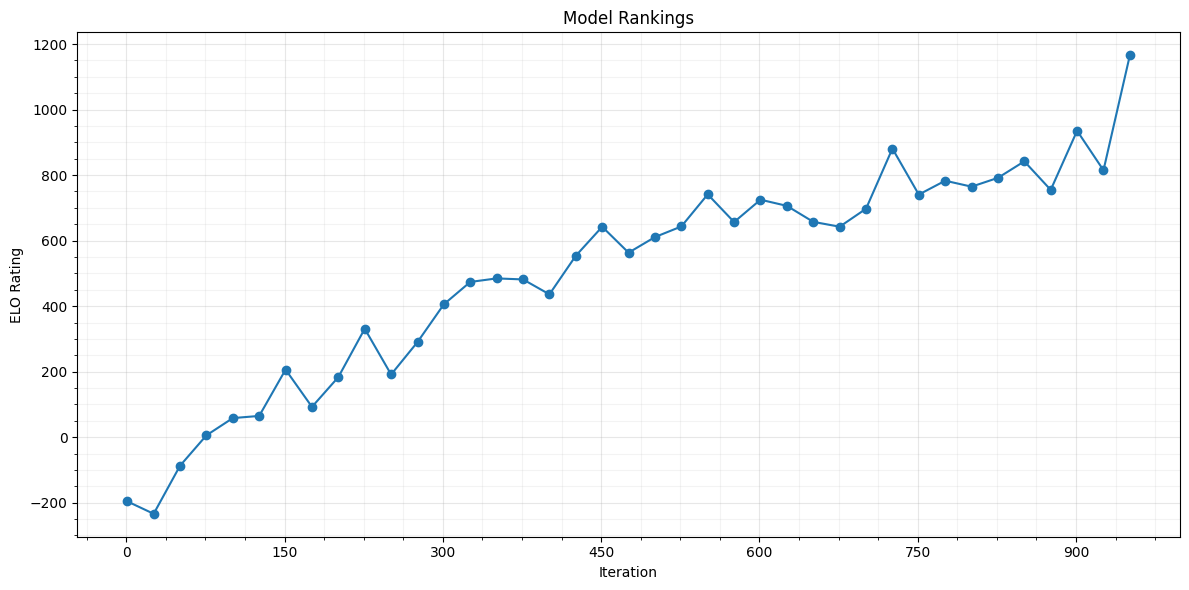

In [10]:
iterations = [int(name.split("_")[-1].split(".")[0]) for name in model_name]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(iterations, elos, marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("ELO Rating")
ax.set_title("Model Rankings")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.15)
fig.tight_layout()
plt.show()